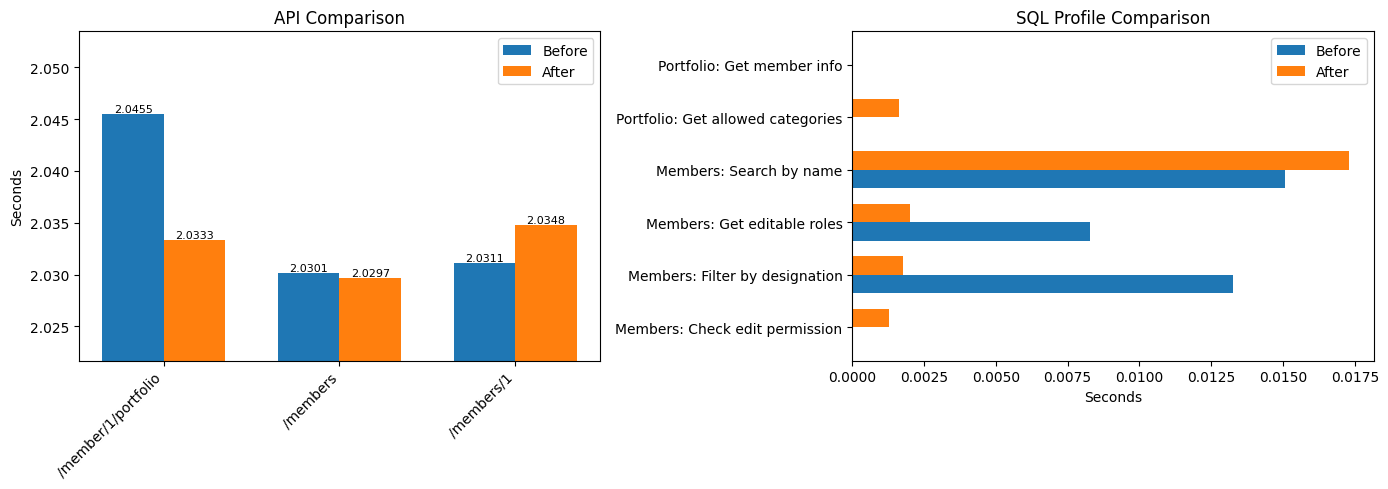

In [5]:
import json
import matplotlib.pyplot as plt
import os
import glob

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'benchmarks'))
GRAPH_DIR = os.path.join(BASE_DIR, 'graphs')
os.makedirs(GRAPH_DIR, exist_ok=True)

def load_json(path):
    if not os.path.exists(path):
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

api_before = glob.glob(os.path.join(BASE_DIR, '*api_times_before*.json'))
api_after  = glob.glob(os.path.join(BASE_DIR, '*api_times_after*.json'))
prof_before = glob.glob(os.path.join(BASE_DIR, '*benchmark_profile_before*.json'))
prof_after  = glob.glob(os.path.join(BASE_DIR, '*benchmark_profile_after*.json'))

if not (api_before and api_after and prof_before and prof_after):
    raise FileNotFoundError("Required files not found")

API_BEFORE = api_before[0]
API_AFTER  = api_after[0]
PROF_BEFORE = prof_before[0]
PROF_AFTER  = prof_after[0]

def plot_combined():
    api_b = load_json(API_BEFORE)
    api_a = load_json(API_AFTER)
    prof_b = load_json(PROF_BEFORE)
    prof_a = load_json(PROF_AFTER)

    api_before_dict = {p['endpoint']: float(p['time']) for p in api_b}
    api_after_dict  = {p['endpoint']: float(p['time']) for p in api_a}
    api_keys = sorted(set(api_before_dict) & set(api_after_dict))

    prof_before_dict = {p['desc']: float(p['execution_time']) for p in prof_b}
    prof_after_dict  = {p['desc']: float(p['execution_time']) for p in prof_a}
    prof_keys = sorted(set(prof_before_dict) & set(prof_after_dict))[:10]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    width = 0.35

    x = range(len(api_keys))
    before_vals = [api_before_dict[k] for k in api_keys]
    after_vals  = [api_after_dict[k] for k in api_keys]

    axes[0].bar([i - width/2 for i in x], before_vals, width, label='Before')
    axes[0].bar([i + width/2 for i in x], after_vals, width, label='After')

    all_vals = before_vals + after_vals
    ymin = min(all_vals)
    ymax = max(all_vals)
    margin = (ymax - ymin) * 0.5 if ymax != ymin else 0.01
    axes[0].set_ylim(ymin - margin, ymax + margin)

    for i, v in enumerate(before_vals):
        axes[0].text(i - width/2, v, f"{v:.4f}", ha='center', va='bottom', fontsize=8)
    for i, v in enumerate(after_vals):
        axes[0].text(i + width/2, v, f"{v:.4f}", ha='center', va='bottom', fontsize=8)

    axes[0].set_title('API Comparison')
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(api_keys, rotation=45, ha='right')
    axes[0].set_ylabel('Seconds')
    axes[0].legend()

    y = range(len(prof_keys))

    axes[1].barh([i - width/2 for i in y],
                 [prof_before_dict[k] for k in prof_keys],
                 height=width, label='Before')

    axes[1].barh([i + width/2 for i in y],
                 [prof_after_dict[k] for k in prof_keys],
                 height=width, label='After')

    axes[1].set_title('SQL Profile Comparison')
    axes[1].set_yticks(list(y))
    axes[1].set_yticklabels(prof_keys)
    axes[1].set_xlabel('Seconds')
    axes[1].legend()

    plt.tight_layout()
    output_path = os.path.join(GRAPH_DIR, 'combined_comparison.png')
    plt.savefig(output_path)
    plt.show()

plot_combined()


## EXPLAIN Plan Samples
Below are the EXPLAIN outputs captured in `callhub_benchmark_profile.json`. Each entry has an `explain` array containing explain rows. You can inspect these programmatically or copy them into the report PDF.

In [4]:
# Print a compact representation of the EXPLAIN for each profile snapshot
import glob, os
profile_files = sorted(glob.glob(os.path.join(os.getcwd(), 'benchmarks', 'callhub_benchmark_profile_*.json')))
if os.path.exists('callhub_benchmark_profile_latest.json'):
    profile_files.append('callhub_benchmark_profile_latest.json')

for pf in profile_files:
    data = load_json(pf)
    if not data:
        continue
    print('===', os.path.basename(pf))
    for item in data:
        print('---', item.get('desc'))
        explain = item.get('explain', [])
        if isinstance(explain, list):
            for row in explain[:5]:
                print(row)
        else:
            print(explain)
        print('\n')

=== callhub_benchmark_profile_latest.json
--- Portfolio: Get member info
[1, 'SIMPLE', 'Members', None, 'const', 'PRIMARY,idx_members_is_deleted,idx_members_isdeleted_fullname', 'PRIMARY', '4', 'const', 1, 100.0, None]


--- Portfolio: Get allowed categories
[1, 'SIMPLE', 'mra', None, 'ref', 'role_id,idx_mra_member_id', 'idx_mra_member_id', '4', 'const', 1, 100.0, 'Using temporary']
[1, 'SIMPLE', 'rp', None, 'ref', 'idx_rp_role_id,idx_rp_category_id', 'idx_rp_role_id', '5', 'callhub_db.mra.role_id', 5, 10.0, 'Using where']


--- Members: Check edit permission
[1, 'SIMPLE', 'Roles', None, 'const', 'role_title,idx_roles_role_title', 'role_title', '202', 'const', 1, 100.0, None]


--- Members: Get editable roles
[1, 'SIMPLE', 'Roles', None, 'index', None, 'role_title', '202', None, 12, 100.0, 'Using index']


--- Members: Search by name
[1, 'SIMPLE', 'Members', None, 'ALL', None, None, None, None, 4870, 11.11, 'Using where']


--- Members: Filter by designation
[1, 'SIMPLE', 'Members', No